In [6]:
import sys


sys.path.append("/gpfs/home/jd925/Adding_stellar_masses/simple_sim")

import Sharding_manager as SM

import Maths_funcs as MF

import Memory_speed_savers as MSS


sys.path.append("/gpfs/home/jd925/Adding_stellar_masses")


import Building_rho_lms

import Sim_init


import jax
import jaxsp as jsp
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

from jaxsp.constants import GN



In [7]:
m22 = 1000
r_half = 0.01
r_min = 0.1
r_max_enclosing_frac = 0.99
no_radius_bins = 1000
gal_name = 'SegII'
r_cut_kpc = None
L_out_frac = 0.5
r_half_width = 0.05

sim_init = Sim_init.SimInit(m22, r_half, r_min, r_max_enclosing_frac, no_radius_bins, gal_name,
                                         r_cut_kpc=r_cut_kpc)

sim_init.u = jsp.set_schroedinger_units(m22)
sim_init.L_out_frac = L_out_frac
sim_init.r_half_width = r_half_width

use_multi_gpu = False

sharding = SM.ShardingManager(use_multi_gpu)
compute_dtype = jnp.complex64
r_chunk_size = 100
ramp_time = 0
frozen = False
sph_sym = False
particle_chunk_size = 100


rho_builder = Building_rho_lms.Rho_lm_Builder(
    sim_init, sharding, compute_dtype, r_chunk_size, ramp_time,
    frozen=frozen, sph_sym=sph_sym,
    particle_chunk_size=particle_chunk_size,
)

sim_init.sharding = sharding
# Particle_ICs() builds the static density via self.Rho_lm_builder.
sim_init.Rho_lm_builder = rho_builder

sim_init.Check_if_exists()

sim_init.R_j_r, sim_init.radial_eigenmode_params = sim_init.Load_files()

# Truncating_L reads the *original* l max to set L_max_out, so it has
# to run before the radial modes are pruned against that cut.
sim_init.Truncating_L()

# Has to run before lm_pairs is built, so the (l, m) table only covers
# the l values that actually survive the cut.
sim_init.Prune_radial_modes()

sim_init.lm_pairs = jnp.asarray(MSS.build_lm_pairs(sim_init.l))
print(f"(l, m) pairs to solve for: {sim_init.lm_pairs.shape[0]} "
        f"(l = 0 .. {int(sim_init.L_max_out) - 1})")

sim_init.Setup_rebound()


no_of_particles = 1000
r = sim_init.r

Rho_lm_builder = sim_init.Rho_lm_builder

G = GN.value * (sim_init.u.from_cm**3) / (sim_init.u.from_g * sim_init.u.from_s**2)

Loading precomputed R_j_r from /gpfs/home/jd925/Adding_stellar_masses/simple_sim/../precomputed_wf/SegII/precomputed_R_j_r_m22_1000_rbins_1000.npz...
No r_cut set - keeping the full radial grid out to 6.48 kpc (1000 bins).
l max from jaxsp: 336
SphHT bandwidth truncated by L_out_frac=0.5: L_max_out = 336 (natural 2L-1 = 673, floor L = 337)
Radial-mode pruning (l >= L_max_out=336): dropped 1 of 51612 radial modes (0.0%), 51611 kept.
Eigenmode library uploaded: 0.85 GB, on a single device.
(l, m) pairs to solve for: 112896 (l = 0 .. 335)


In [8]:
def Teodori_ICs(M_plummer, a_plummer):

    def sample_plummer_positions(a_plummer):

        key1 = jax.random.PRNGKey(42)

        # Positions

        X = jax.random.uniform(key1, shape=(3, no_of_particles), minval=0.0, maxval=1.0)

        X1 = X[0]
        X2 = X[1]
        X3 = X[2]

        # Truncated at the grid's outer radius: psi_r below is not tabulated
        # past it, and the untruncated Plummer tail runs to infinity. With
        # s = r / sqrt(r^2 + a^2) the enclosed mass fraction is just s^3.
        s_max = r[-1] / jnp.sqrt(r[-1]**2 + a_plummer**2)

        s = (X1 * s_max**3)**(1/3)

        star_radii = a_plummer * s / jnp.sqrt(1 - s**2)

        star_z = star_radii * (1 - 2 * X2)
        star_x = jnp.sqrt(star_radii**2 - star_z**2) * jnp.cos(2 * jnp.pi * X3)
        star_y = jnp.sqrt(star_radii**2 - star_z**2) * jnp.sin(2 * jnp.pi * X3)

        return star_x, star_y, star_z, star_radii

    def build_f1():

        # initialise() still has to run - it builds the amplitudes, the
        # radial mode table and the static background the ramp blends
        # against - but its return value, the time-averaged density, is
        # NOT the potential to invert in. The stars are integrated in the
        # monopole of the realised wavefunction at step 0, which differs
        # from the time average by the eigenmode interference terms; see
        # Rho_lm_Builder.initial_rho_monopole.
        Rho_lm_builder.initialise()

        rho_mono = Rho_lm_builder.initial_rho_monopole()

        # # Cumulative enclosed mass M_enc(r) on the radial grid; interpolated
        # # per particle below. SSF.Enclosed_mass applies the 4π r² factor.
        M_enc_arr = MF.Enclosed_mass(r, rho_mono)

        # Enclosed_mass starts its cumsum at r[0], so M_enc_arr[0] is
        # exactly zero and dpsi_dr[0] would divide by it. Fold the core in here
        # rather than at the particles: everything below runs off M_enc_arr.
        r_inner_edge = r[0]
        rho_core = rho_mono[0]
        M_core = 4/3 * jnp.pi * rho_core * r_inner_edge**3

        M_enc_arr = M_enc_arr + M_core

        M_tot = M_enc_arr[-1]

        # psi on the simulation grid, with psi(r[-1]) = 0.
        integrand_in = G * M_enc_arr / r**2

        dA_in = 0.5 * (integrand_in[1:] + integrand_in[:-1]) * jnp.diff(r)

        psi_in = jnp.concatenate([jnp.cumsum(dA_in[::-1])[::-1], jnp.array([0.0])])

        # --- Keplerian tail -------------------------------------------------
        # psi(r[-1]) = 0 is only the right zero point if r[-1] is
        # infinity. All the halo mass is inside it, so outside the potential
        # is Keplerian and psi(r_max) = G M_tot / r_max - at m22 = 10 that is
        # 20.87 against psi_max = 237.6, a 9% offset, not a constant that
        # cancels. Zeroing it declares every star with v > sqrt(2 psi(r))
        # unbound and drops it, which is exactly the mass the DF then cannot
        # put back: the round trip rho -> f -> rho came back 94% LOW at
        # a_plummer = 0.1, and that error is structural - refining the
        # quadrature to 128000 nodes does not move it.
        #
        # So tabulate out to where the Plummer tail is negligible, with
        # M_enc frozen at M_tot and rho_dm = 0 beyond the grid. This assumes
        # the halo is isolated out there, which is the same assumption the
        # psi -> 0 boundary condition already makes, only now applied
        # consistently. Stars are still SAMPLED only inside r[-1] -
        # the sim has no forces beyond it - this just fixes their energies.
        #
        # Costs nothing where the old convention was already adequate: at
        # a_plummer = 0.01 sigma_3D moves by +0.00% and no star gains enough
        # energy to leave the grid.
        s_out = (1.0 - 1e-10)**(1/3)
        r_out = jnp.maximum(a_plummer * s_out / jnp.sqrt(1 - s_out**2),
                            r[-1] * 10.0)

        r_tail = jnp.logspace(jnp.log10(r[-1] * 1.0001), jnp.log10(r_out), 2000)

        r_full = jnp.concatenate([r, r_tail])

        M_full = jnp.concatenate([M_enc_arr, jnp.full_like(r_tail, M_tot)])

        rho_bg = jnp.concatenate([rho_mono, jnp.zeros_like(r_tail)])

        psi_r = jnp.concatenate([psi_in + G * M_tot / r[-1],
                                 G * M_tot / r_tail])
        # --------------------------------------------------------------------

        dpsi_dr = - G * M_full / r_full**2

        drho_dr = -15 * M_plummer * r_full / (4 * jnp.pi * a_plummer**5) * (1 + r_full**2 / a_plummer**2)**(-7/2)

        drho_dpsi = drho_dr / dpsi_dr

        d2rho_dr2 = -15 * M_plummer / (4 * jnp.pi * a_plummer**5) * ((1 + r_full**2 / a_plummer**2)**(-7/2) - r_full * 7 * (1 + r_full**2/a_plummer**2)**(-9/2) * r_full/a_plummer**2)

        d2psi_dr2 = 2 * G * M_full / r_full**3 - 4 * jnp.pi * G * rho_bg

        d2rho_dpsi2 = (d2rho_dr2 * dpsi_dr - drho_dr * d2psi_dr2) / dpsi_dr**3

        # Tabulate f on psi(r) itself, NOT on logspace(log10(psi_max) - 8,
        # log10(psi_max), 1000). The stars sit deep inside the soliton core
        # where psi is nearly flat - at m22 = 10, a_plummer = 0.01, the whole
        # region r < a_plummer spans psi = 236.16 .. 237.59, i.e. 0.0026 dex,
        # while a log grid of 1000 nodes over 8 decades steps 0.008 dex. That
        # is ONE node across the radii holding a third of the stellar mass,
        # and the round trip rho -> f -> rho came back 222% high there.
        # Matching the eps nodes to the radial grid puts them where psi
        # actually has structure and makes the interp below exact at the
        # nodes; it beats brute-forcing the log grid to 64000 nodes (0.08%
        # vs 0.47% error) without the 512 MB (n_eps, n_u) array.
        #
        # psi_r is strictly decreasing - integrand = G M_enc / r^2 > 0 - so
        # the reverse is strictly increasing and needs no unique() (which
        # would make the shape dynamic). Drop psi_r[-1], which is exactly 0:
        # f ~ eps^(-1/2) diverges there and the velocity sampler takes
        # log(epsilons).
        epsilons = psi_r[::-1][1:]

        # psi_r decreases outwards, jnp.interp needs an ascending abscissa.
        psi_asc = psi_r[::-1]
        d2rho_dpsi2_asc = d2rho_dpsi2[::-1]

        # Eq. (A5)'s Q = sqrt(E - psi) removes the 1/sqrt(E - psi) singularity;
        # writing Q = sqrt(E) * u then puts every energy on the same u nodes, so
        # the whole inversion is one (n_eps, n_u) array rather than a per-energy
        # integral with its own upper limit.
        #
        # u is clustered as t^2, NOT uniform. The integrand is sampled at
        # eps (1 - u^2), so a uniform u steps 1 - u^2 by only ~1/n_u^2 = 1e-6
        # near u = 0 - and the stars sit where psi is flat, so the whole
        # stellar body can span less than that in relative psi and simply not
        # be resolved. At a_plummer = 5e-5 the round trip was 94% off with a
        # uniform grid; t^2 brings it to 0.19% at the same 1000 nodes, which
        # is what a uniform grid needs 16000 nodes to reach. Identical to
        # four decimals wherever the uniform grid was already adequate.
        u_q = jnp.linspace(0.0, 1.0, 1000)**2

        integrand_Q = jnp.interp(epsilons[:, None] * (1 - u_q[None, :]**2), psi_asc, d2rho_dpsi2_asc) #evaluating at psi = epsilon(1 - u^2) - this changes variables from psi to u

        dA_Q = 0.5 * (integrand_Q[:, 1:] + integrand_Q[:, :-1]) * jnp.diff(u_q)

        second_term = jnp.sqrt(epsilons) * jnp.sum(dA_Q, axis=1)

        # drho_dpsi[-1] is the boundary term, now at r_full[-1] where the
        # Plummer tail has 1e-10 of its mass left outside.
        f_eps = (drho_dpsi[-1] / jnp.sqrt(epsilons) + 2 * second_term) / (jnp.sqrt(8.0) * jnp.pi**2)

        # A NEGATIVE f is not always quadrature noise. Where it appears at
        # high eps - the most bound orbits, i.e. the core - it is Eddington's
        # non-negativity condition failing: no isotropic DF reproduces this
        # (rho_star, psi) pair at all, and no grid or precision fixes that.
        # For a Plummer tracer as extended as the halo it is emphatic: at
        # a_plummer = 0.6, 622 of 2999 nodes go negative, reaching
        # eps / psi_max = 1. Clipping silently turned "these ICs are
        # impossible" into "here are some quietly wrong ICs", so refuse them
        # instead. Only the far tail, eps < 1e-2 psi_max, is treated as noise.
        core_negative = (f_eps < 0) & (epsilons > 1e-2 * epsilons[-1])

        if bool(jnp.any(core_negative)):
            worst = float(jnp.max(epsilons[core_negative]) / epsilons[-1])
            raise ValueError(
                f"No isotropic distribution function exists for this tracer in "
                f"this potential: the Eddington f(eps) is negative at "
                f"{int(core_negative.sum())} of {epsilons.size} energies, up to "
                f"eps / psi_max = {worst:.3g}. This is Eddington's non-negativity "
                f"condition failing, not a resolution problem - refining the "
                f"quadrature will not help. a_plummer = {a_plummer} is too "
                f"extended for this halo; reduce it, or move to an anisotropic "
                f"DF (Osipkov-Merritt) which has the freedom to realise it."
            )

        # Far-tail noise only, by the check above.
        f_eps = jnp.clip(f_eps, 0.0, None)

        return r_full, psi_r, epsilons, f_eps

    def sample_plummer_velocities(star_radii, r_tab, psi_r, epsilons, f_eps):

        psi_star = jnp.interp(star_radii, r_tab, psi_r)

        v_esc = jnp.sqrt(2 * psi_star)

        # One shared w = v / v_esc grid, so every star's CDF sits on the same
        # abscissa and the inversion is a single batched interp. Clustered as
        # t^2 for the same reason as u_q above: eps_w = psi_star (1 - w^2)
        # has to resolve the top of f, where the stars are.
        w = jnp.linspace(0.0, 1.0, 1000)**2

        eps_w = psi_star[:, None] * (1 - w[None, :]**2)

        # f spans many decades and epsilons is log-spaced, so interpolate in log.
        f_w = jnp.exp(jnp.interp(jnp.log(jnp.clip(eps_w, epsilons[0], epsilons[-1])),
                                jnp.log(epsilons), jnp.log(jnp.clip(f_eps, 1e-300, None))))

        # Eq. (A7). This has to be a cumulative INTEGRAL, not jnp.cumsum of
        # the integrand: with the uniform w this used to be, the constant dw
        # cancelled against the normalisation below and the bare cumsum was
        # right, but w is clustered now and dropping dw biases the CDF
        # towards the dense end (it cost 13% in sigma_3D at a_plummer = 0.01).
        integrand_w = f_w * w[None, :]**2

        dcdf = 0.5 * (integrand_w[:, 1:] + integrand_w[:, :-1]) * jnp.diff(w)

        cdf = jnp.concatenate([jnp.zeros((integrand_w.shape[0], 1)),
                               jnp.cumsum(dcdf, axis=1)], axis=1)

        cdf = cdf / cdf[:, -1:]

        key2 = jax.random.PRNGKey(43)

        X = jax.random.uniform(key2, shape=(3, no_of_particles), minval=0.0, maxval=1.0)

        X4 = X[0]
        X5 = X[1]
        X6 = X[2]

        # vmapped rather than batched because the abscissa differs row to row.
        v = jax.vmap(lambda c, q: jnp.interp(q, c, w))(cdf, X4) * v_esc

        # beta0 = 0 collapses Eqs. (A8)-(A10) to an isotropic direction,
        # independent of r_hat.
        vel_z = v * (1 - 2 * X5)
        vel_x = jnp.sqrt(v**2 - vel_z**2) * jnp.cos(2 * jnp.pi * X6)
        vel_y = jnp.sqrt(v**2 - vel_z**2) * jnp.sin(2 * jnp.pi * X6)

        return vel_x, vel_y, vel_z

    star_x, star_y, star_z, star_radii = sample_plummer_positions(a_plummer)

    r_tab, psi_r, epsilons, f_eps = build_f1()

    vel_x, vel_y, vel_z = sample_plummer_velocities(star_radii, r_tab, psi_r, epsilons, f_eps)

    # The Kepler tail gives stars near the grid edge a real, non-zero escape
    # speed, so unlike under psi(r_max) = 0 some can now be energetic enough
    # to leave r[-1] - where there is no tabulated force. Sampling still
    # truncates positions at the grid, so this is only a warning, but a large
    # count means a_plummer is pushing past what the grid can integrate.
    v_sq = vel_x**2 + vel_y**2 + vel_z**2
    psi_edge = jnp.interp(r[-1], r_tab, psi_r)
    n_escaping = int(jnp.sum(0.5 * v_sq > jnp.interp(star_radii, r_tab, psi_r) - psi_edge))

    if n_escaping:
        print(f"Warning: {n_escaping} of {no_of_particles} stars have enough "
              f"energy to pass r_max = {float(r[-1]):.4g}, where no forces are "
              f"tabulated. Consider reducing a_plummer = {a_plummer}.")

    init_pos = jnp.stack([star_x, star_y, star_z], axis=1)

    init_vel = jnp.stack([vel_x, vel_y, vel_z], axis=1)

    return init_pos, init_vel, f_eps, epsilons, r_tab, psi_r


In [9]:
M_plummer = 1e6 * sim_init.u.from_Msun
a_plummer = r_half * 0.7 * sim_init.u.from_Kpc


# r_tab / psi_r are the Kepler-extended tabulation build_f1 inverts on; the
# diagnostics below need them, and rebuilding them by hand would let the two
# conventions drift apart again.
init_pos, init_vel, f_eps, epsilons, r_tab, psi_r = Teodori_ICs(M_plummer, a_plummer)


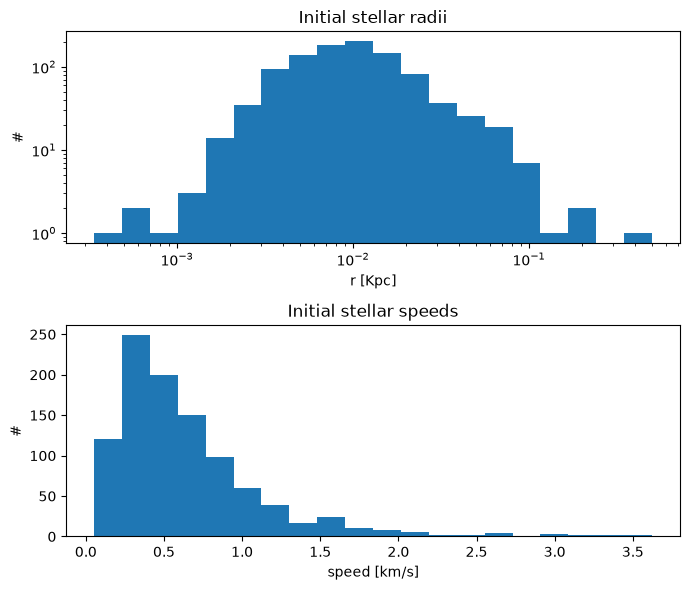

In [10]:
# init_pos / init_vel stay in code units: the kpc / km-s copies are local to
# this plot. Rescaling them in place instead (init_pos = init_pos * to_Kpc)
# breaks the diagnostics below, which bin star radii against the code-unit
# grid r, and double-converts if this cell is ever re-run.

r_vals_kpc = jnp.linalg.norm(init_pos, axis=1) * sim_init.u.to_Kpc
speed_kms = jnp.linalg.norm(init_vel, axis=1) * sim_init.u.to_kms

fig, ax = plt.subplots(2, 1, figsize=(7, 6))

# Log bins, not 20 linear ones under a log x-axis - the Plummer core holds
# most of the stars and linear bins collapse it into the first bar.
ax[0].hist(r_vals_kpc, bins=np.logspace(np.log10(float(r_vals_kpc.min())),
                                        np.log10(float(r_vals_kpc.max())), 21))
ax[0].set_xlabel("r [Kpc]")
ax[0].set_ylabel("#")
ax[0].set_title("Initial stellar radii")
ax[0].set_xscale('log')
ax[0].set_yscale('log')

ax[1].hist(speed_kms, bins=20)
ax[1].set_xlabel("speed [km/s]")
ax[1].set_ylabel("#")
ax[1].set_title("Initial stellar speeds")

plt.tight_layout()
plt.show()


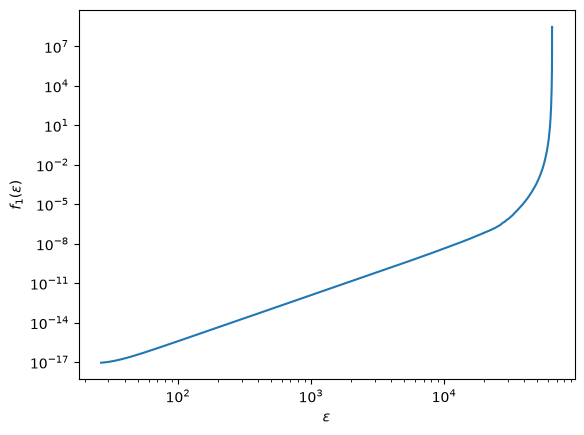

In [11]:
plt.plot(epsilons, f_eps)
plt.xscale('log')
plt.yscale('log')
plt.ylabel(r'$f_1(\epsilon)$')
plt.xlabel(r'$\epsilon$')
plt.show()

f is tabulated out to 853 kpc (sim grid runs to 6.48 kpc)
scoring over 0.00154 - 0.0854 kpc (362 grid points)
  max |rho_pred / rho_Plummer - 1| = 0.072% at r = 0.0323 kpc
  PASS


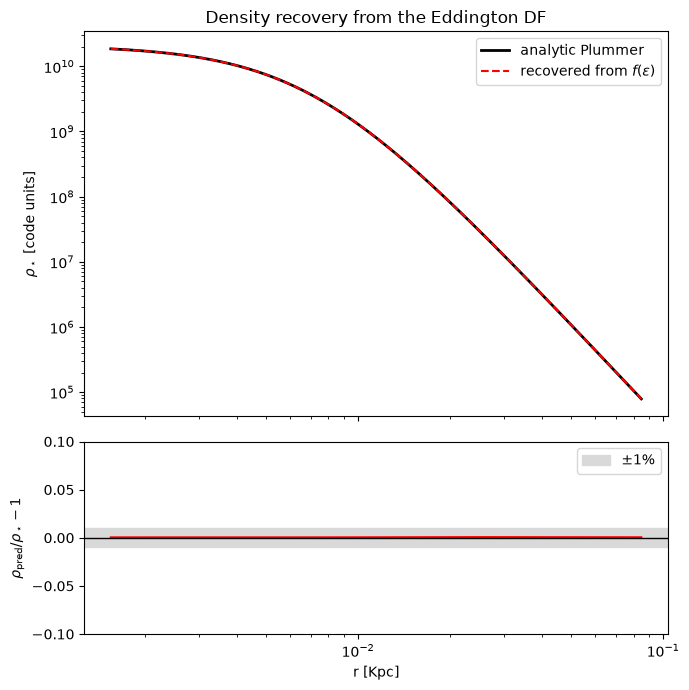

In [12]:
# --- Diagnostic 1: does f(eps) integrate back to the Plummer density? ---
#
# The Eddington inversion is only self-consistent if
#     rho(r) = 4 pi int_0^psi(r) f(eps) sqrt(2 (psi - eps)) d eps
# returns the rho it was built from. Substituting eps = psi (1 - u^2), exactly
# as build_f1 and the velocity sampler both do, gives
#     rho_pred(r) = 8 sqrt(2) pi psi^(3/2) int_0^1 f(psi (1 - u^2)) u^2 du,
# i.e. the same u-grid quadrature that normalises the velocity CDF - so this
# also says whether the u nodes are placed well enough there.
#
# Catches: the boundary term drho_dpsi[-1], the M_core patch at r[0], the sign
# of dpsi_dr, the Q-substitution, the eps and u node placement, and whether
# no_radius_bins resolves the core. Does NOT catch psi being the wrong
# potential: f was built from rho(psi) with this same psi, so that error
# cancels here. Only evolving the stars in the real forces tests that.
#
# psi_r and r_tab come straight from Teodori_ICs now. They used to be rebuilt
# inline, which was fine while psi(r_max) = 0 but silently compares two
# different potentials now that build_f1 adds the Keplerian tail.

u_q = jnp.linspace(0.0, 1.0, 1000)**2  # clustered, matching build_f1

eps_grid = psi_r[:, None] * (1 - u_q[None, :]**2)

# Log-interp, matching sample_plummer_velocities: f spans many decades.
f_grid = jnp.exp(jnp.interp(jnp.log(jnp.clip(eps_grid, epsilons[0], epsilons[-1])),
                            jnp.log(epsilons), jnp.log(jnp.clip(f_eps, 1e-300, None))))

dA_u = 0.5 * (f_grid[:, 1:] * u_q[None, 1:]**2 + f_grid[:, :-1] * u_q[None, :-1]**2) * jnp.diff(u_q)

rho_pred = 8 * jnp.sqrt(2.0) * jnp.pi * psi_r**1.5 * jnp.sum(dA_u, axis=1)

rho_plummer = 3 * M_plummer / (4 * jnp.pi * a_plummer**3) * (1 + r_tab**2 / a_plummer**2)**(-5/2)

# Where psi drops below the tabulated floor the clip above pins f at
# f(epsilons[0]) and rho_pred is meaningless, so the comparison stops there.
tabulated = psi_r > epsilons[0]

# Judge the agreement over the radii that actually hold stars: 1% to 99% of the
# Plummer's enclosed mass, capped at the sim grid, since nothing is sampled
# outside it however far the tabulation runs.
def plummer_radius_at_mass_fraction(frac):
    s = frac ** (1 / 3)
    return a_plummer * s / jnp.sqrt(1 - s**2)


r_lo = plummer_radius_at_mass_fraction(0.01)
r_hi = jnp.minimum(plummer_radius_at_mass_fraction(0.99), r[-1])

ratio = rho_pred / rho_plummer
scored = tabulated & (r_tab >= r_lo) & (r_tab <= r_hi)

worst = float(jnp.max(jnp.abs(ratio[scored] - 1.0)))
r_worst = float(r_tab[scored][jnp.argmax(jnp.abs(ratio[scored] - 1.0))])

print(f"f is tabulated out to {float(r_tab[tabulated][-1]) * sim_init.u.to_Kpc:.3g} kpc "
      f"(sim grid runs to {float(r[-1]) * sim_init.u.to_Kpc:.3g} kpc)")
print(f"scoring over {float(r_lo) * sim_init.u.to_Kpc:.3g} - {float(r_hi) * sim_init.u.to_Kpc:.3g} kpc "
      f"({int(scored.sum())} grid points)")
print(f"  max |rho_pred / rho_Plummer - 1| = {worst:.3%} at r = {r_worst * sim_init.u.to_Kpc:.3g} kpc")
print("  " + ("PASS" if worst < 0.01 else "FAIL - the inversion does not reproduce its own rho"))

fig, ax = plt.subplots(2, 1, figsize=(7, 7), sharex=True,
                       gridspec_kw={'height_ratios': [2, 1]})

ax[0].loglog(r_tab[scored] * sim_init.u.to_Kpc, rho_plummer[scored],
             'k-', lw=2, label='analytic Plummer')
ax[0].loglog(r_tab[scored] * sim_init.u.to_Kpc, rho_pred[scored],
             'r--', lw=1.5, label=r'recovered from $f(\epsilon)$')
ax[0].set_ylabel(r"$\rho_\star$ [code units]")
ax[0].set_title("Density recovery from the Eddington DF")
ax[0].legend()

ax[1].semilogx(r_tab[scored] * sim_init.u.to_Kpc, ratio[scored] - 1.0, 'r-')
ax[1].axhline(0.0, color='k', lw=1)
ax[1].axhspan(-0.01, 0.01, color='0.85', zorder=0, label=r'$\pm 1\%$')
ax[1].set_ylim(-0.1, 0.1)
ax[1].set_xlabel("r [Kpc]")
ax[1].set_ylabel(r"$\rho_{\rm pred} / \rho_\star - 1$")
ax[1].legend()

plt.tight_layout()
plt.show()


<v_x^2> / <v^2> = 0.3313   (isotropic: 0.3333 +/- 0.0131, -0.2 sigma)
<v_y^2> / <v^2> = 0.3212   (isotropic: 0.3333 +/- 0.0131, -0.9 sigma)
<v_z^2> / <v^2> = 0.3475   (isotropic: 0.3333 +/- 0.0131, +1.1 sigma)

beta over 0.00154 - 0.0854 kpc (8 bins, 122-123 stars each)
  max |beta|         = 0.4672  (scatter alone gives ~0.21)
  max |beta| / sigma = 4.70
  FAIL - beta is inconsistent with 0


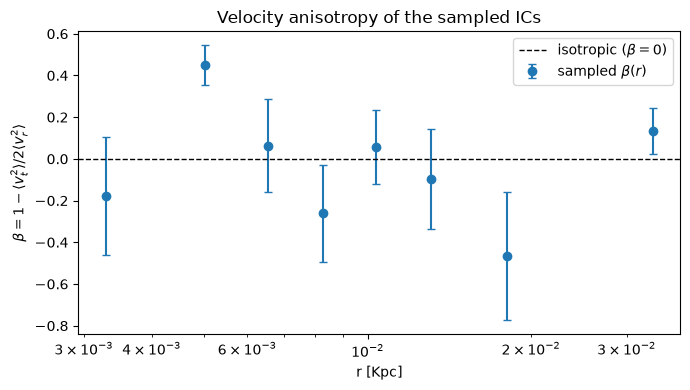

In [13]:
# --- Diagnostic 2: is the sampled velocity field isotropic? ---
#
# sample_plummer_velocities builds directions with beta0 = 0, so the anisotropy
# parameter
#     beta(r) = 1 - <v_t^2> / (2 <v_r^2>)
# has to come out at zero in every radial bin. That tests the direction
# construction (vel_z = v (1 - 2 X5), then an azimuth from X6) and, more
# usefully, whether the speed drawn from the CDF ends up correlated with
# position in a way it should not be: a non-zero beta(r) means the stars are on
# preferentially radial or circular orbits, which this DF does not describe.
#
# Judge this on the pulls, not on beta itself. At 1000 particles over 8 bins a
# bin holds ~125 stars, where beta scatters by ~0.13 for free - on a synthetic
# isotropic sample max |beta| lands at ~0.3 while max |pull| stays below ~2.3.
# Bins are equal-occupancy rather than log-spaced for exactly that reason: log
# bins leave the outermost one with ~35 stars, where beta scatters by ~0.5 and
# the bin says nothing.
#
# init_pos / init_vel are in code units and stay that way - the plotting cell
# above keeps its kpc / km-s copies local - so this cell can run in any order.
# beta itself is dimensionless, but the radial binning below is not, so the
# assert stays as a guard against anything reintroducing an in-place rescale.

pos = jnp.asarray(init_pos)
vel = jnp.asarray(init_vel)

r_star = jnp.linalg.norm(pos, axis=1)

assert float(jnp.max(r_star)) <= float(r[-1]) * 1.001, (
    "star radii exceed the grid's outer radius - init_pos has already been "
    "converted to kpc. Re-run the Teodori_ICs cell above first.")

# Global check first: an isotropic sample has <v_i^2> / <v^2> = 1/3 on every
# Cartesian axis. Independent of any binning, so it isolates the direction
# sampling from the radial structure. The expected scatter is calibrated from
# 300 synthetic isotropic samples at 1000 particles.
v2 = jnp.sum(vel**2, axis=1)

axis_sigma = 0.0131 * np.sqrt(1000 / no_of_particles)

for i, axis_name in enumerate("xyz"):
    frac = float(jnp.mean(vel[:, i]**2) / jnp.mean(v2))
    pull = (frac - 1 / 3) / axis_sigma
    print(f"<v_{axis_name}^2> / <v^2> = {frac:.4f}   "
          f"(isotropic: 0.3333 +/- {axis_sigma:.4f}, {pull:+.1f} sigma)")

r_hat = pos / r_star[:, None]
v_r = jnp.sum(vel * r_hat, axis=1)
v_t2 = v2 - v_r**2

# Bin over the radii that actually hold stars: 1% to 99% of the truncated
# Plummer's enclosed mass. Re-derived here rather than taken from the
# density-recovery cell above, so this cell runs on its own.
s_max = r[-1] / jnp.sqrt(r[-1]**2 + a_plummer**2)


def plummer_radius_at_mass_fraction(frac):
    s = (frac * s_max**3)**(1 / 3)
    return a_plummer * s / jnp.sqrt(1 - s**2)


r_lo = float(plummer_radius_at_mass_fraction(0.01))
r_hi = float(plummer_radius_at_mass_fraction(0.99))

r_np = np.asarray(r_star)
v_r2_np = np.asarray(v_r**2)
v_t2_np = np.asarray(v_t2)

in_range = (r_np >= float(r_lo)) & (r_np <= float(r_hi))

no_bins = 8
bin_edges = np.quantile(r_np[in_range], np.linspace(0.0, 1.0, no_bins + 1))
bin_edges[-1] *= 1.0001  # so the outermost star lands inside the last bin

rng = np.random.default_rng(0)
no_boot = 200


def beta_of(vr2, vt2):
    return 1.0 - np.mean(vt2) / (2.0 * np.mean(vr2))


bin_centres, betas, beta_errs, counts = [], [], [], []

for lo, hi in zip(bin_edges[:-1], bin_edges[1:]):

    in_bin = in_range & (r_np >= lo) & (r_np < hi)
    n = int(in_bin.sum())

    # Below ~20 stars the bootstrap spread is wider than any anisotropy worth
    # detecting, so the bin says nothing either way.
    if n < 20:
        continue

    vr2_bin = v_r2_np[in_bin]
    vt2_bin = v_t2_np[in_bin]

    boot = np.array([
        beta_of(vr2_bin[idx], vt2_bin[idx])
        for idx in rng.integers(0, n, size=(no_boot, n))
    ])

    bin_centres.append(np.median(r_np[in_bin]))
    betas.append(beta_of(vr2_bin, vt2_bin))
    beta_errs.append(boot.std())
    counts.append(n)

bin_centres = np.array(bin_centres)
betas = np.array(betas)
beta_errs = np.array(beta_errs)

pulls = betas / beta_errs

print(f"\nbeta over {float(r_lo) * sim_init.u.to_Kpc:.3g} - {float(r_hi) * sim_init.u.to_Kpc:.3g} kpc "
      f"({len(betas)} bins, {min(counts)}-{max(counts)} stars each)")
print(f"  max |beta|         = {np.abs(betas).max():.4f}  (scatter alone gives ~{np.mean(beta_errs):.2f})")
print(f"  max |beta| / sigma = {np.abs(pulls).max():.2f}")
print("  " + ("PASS" if np.abs(pulls).max() < 3 else "FAIL - beta is inconsistent with 0"))

fig, ax = plt.subplots(figsize=(7, 4))

ax.errorbar(bin_centres * sim_init.u.to_Kpc, betas, yerr=beta_errs,
            fmt='o', capsize=3, label=r'sampled $\beta(r)$')
ax.axhline(0.0, color='k', lw=1, ls='--', label=r'isotropic ($\beta = 0$)')

ax.set_xscale('log')
ax.set_xlabel("r [Kpc]")
ax.set_ylabel(r"$\beta = 1 - \langle v_t^2 \rangle / 2 \langle v_r^2 \rangle$")
ax.set_title("Velocity anisotropy of the sampled ICs")
ax.legend()

plt.tight_layout()
plt.show()